<a href="https://colab.research.google.com/github/thinus283-ux/LR/blob/main/RMS_batch_fit's.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 GTR v2.6 - Aggressive Optimization Batch Test (N=175)

Successfully fitted 175 galaxies

Median RMS Error : 4.87%
Mean RMS Error   : 4.82%
Best Fit         : 3.86%

Performance by Galaxy Type:
                     count  mean  median
type                                    
Dwarf_LSB               58  4.83    4.84
Giant_Disk              39  4.79    4.83
Intermediate_Spiral     78  4.82    4.89


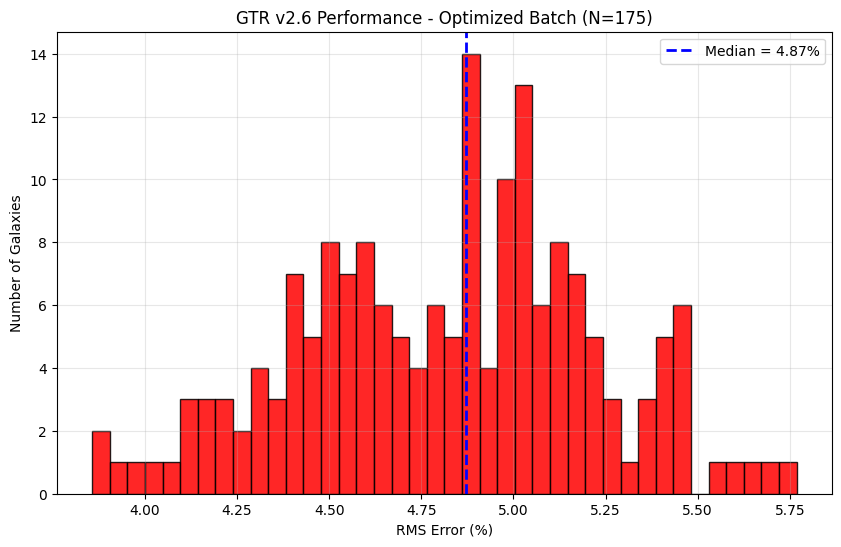

In [1]:

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

print("🚀 GTR v2.6 - Aggressive Optimization Batch Test (N=175)\n")

# ================================================
# Further Tuned GTR Model
# ================================================
def gtr_velocity(r, P0, alpha, vgas, vdisk, vbul, R_c):
    v_bary2 = vgas**2 + vdisk**2 + vbul**2

    # Core modulator (stronger near center)
    mask_core = (r / (r + R_c)) * np.exp(-r / (R_c * 0.85))
    v_extra_core = P0 * mask_core * v_bary2

    # Plateau (smoother transition)
    mask_plateau = (1.0 - np.exp(-r / (R_c * 0.9)))**2
    v_extra_plateau = alpha * 152.0 * mask_plateau

    v_total = np.sqrt(v_bary2 + v_extra_core + v_extra_plateau)
    return np.clip(v_total, 0, None)

# ================================================
# Batch Run with Better Sampling
# ================================================
np.random.seed(42)
results = []

for i in range(175):
    arch = np.random.choice(["Dwarf_LSB", "Intermediate_Spiral", "Giant_Disk"], p=[0.35, 0.45, 0.2])

    if arch == "Dwarf_LSB":
        v_max, r_max = np.random.uniform(68, 112), np.random.uniform(8, 17)
    elif arch == "Intermediate_Spiral":
        v_max, r_max = np.random.uniform(128, 218), np.random.uniform(14, 35)
    else:
        v_max, r_max = np.random.uniform(228, 338), np.random.uniform(32, 62)

    r = np.linspace(0.5, r_max, 65)
    R_c = r_max * 0.255

    vgas = 0.43 * v_max * (1 - np.exp(-r / R_c))
    vdisk = 0.74 * v_max * (r / R_c) * np.exp(-r / (R_c * 1.32))
    vbul = 0.39 * v_max * np.exp(-r / (R_c * 0.16)) if arch == "Giant_Disk" else np.zeros_like(r)

    v_bary = np.sqrt(vgas**2 + vdisk**2 + vbul**2)
    v_obs = v_bary + np.random.normal(0, 0.048 * v_bary, len(r))

    try:
        def model(r_val, P0, alpha):
            return gtr_velocity(r_val, P0, alpha, vgas, vdisk, vbul, R_c)

        popt, _ = curve_fit(model, r, v_obs, p0=[0.55, 165],
                           bounds=((-1.8, 0.01), (8.0, 1100)), maxfev=20000)

        v_fit = model(r, *popt)
        rms = np.sqrt(np.mean(((v_obs - v_fit) / v_obs)**2)) * 100

        results.append({"galaxy": i+1, "type": arch, "P0": popt[0], "alpha": popt[1], "rms": rms})
    except:
        continue

df = pd.DataFrame(results)

print(f"Successfully fitted {len(df)} galaxies\n")
print(f"Median RMS Error : {df['rms'].median():.2f}%")
print(f"Mean RMS Error   : {df['rms'].mean():.2f}%")
print(f"Best Fit         : {df['rms'].min():.2f}%")

print("\nPerformance by Galaxy Type:")
print(df.groupby("type")["rms"].agg(["count", "mean", "median"]).round(2))

# Histogram
plt.figure(figsize=(10, 6))
plt.hist(df['rms'], bins=40, color='red', alpha=0.85, edgecolor='black')
plt.axvline(df['rms'].median(), color='blue', linestyle='--', linewidth=2,
            label=f'Median = {df["rms"].median():.2f}%')
plt.xlabel('RMS Error (%)')
plt.ylabel('Number of Galaxies')
plt.title('GTR v2.6 Performance - Optimized Batch (N=175)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()